In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

yields = pd.read_csv(
    "../data/processed/au_government_yields.csv",
    parse_dates=["Date"]
)

latest = yields.iloc[-1]

current_curve = {
    "2Y": latest["2Y"],
    "3Y": latest["3Y"],
    "5Y": latest["5Y"],
    "10Y": latest["10Y"]
}

print("Current Australian Government Yield Curve")
print(f"Date: {latest['Date'].date()}")
print(f"2Y:  {current_curve['2Y']:.3f}%")
print(f"3Y:  {current_curve['3Y']:.3f}%")
print(f"5Y:  {current_curve['5Y']:.3f}%")
print(f"10Y: {current_curve['10Y']:.3f}%")

Current Australian Government Yield Curve
Date: 2026-08-26
2Y:  4.619%
3Y:  4.598%
5Y:  4.656%
10Y: 5.023%


In [20]:
event_study = pd.read_csv(
    "../outputs/tables/rba_event_study.csv",
    parse_dates=["Meeting Date"]
)

event_study[
    [
        "Meeting Date",
        "Decision Type",
        "2Y Change (bp)",
        "3Y Change (bp)",
        "5Y Change (bp)",
        "10Y Change (bp)"
    ]
]

,Meeting Date,Decision Type,2Y Change (bp),3Y Change (bp),5Y Change (bp),10Y Change (bp)
0,2025-02-18,Cut,5.4,5.5,5.6,5.4
1,2025-04-01,Hold,-0.9,-0.3,0.1,-1.1
2,2025-05-20,Cut,-16.4,-16.9,-15.5,-12.4
3,2025-07-08,Hold,11.6,11.1,10.6,8.1
4,2025-08-12,Cut,-1.1,-1.0,-1.2,-0.6
5,2025-09-30,Hold,1.2,0.9,-0.2,-3.5
6,2025-11-04,Hold,2.5,3.4,3.0,1.5
7,2025-12-09,Hold,9.7,10.2,9.0,5.4
8,2026-02-03,Hike,7.4,6.5,5.6,3.7
9,2026-03-17,Hike,-2.2,-4.2,-4.6,-6.2


In [21]:
# Historical scenario: May 2025 RBA cut
may_2025 = event_study[
    event_study["Meeting Date"] == pd.Timestamp("2025-05-20")
].iloc[0]

# Historical scenario: July 2025 RBA hold
july_2025 = event_study[
    event_study["Meeting Date"] == pd.Timestamp("2025-07-08")
].iloc[0]


scenarios = {
    "Historical Dovish Repricing — May 2025": {
        "2Y": may_2025["2Y Change (bp)"],
        "3Y": may_2025["3Y Change (bp)"],
        "5Y": may_2025["5Y Change (bp)"],
        "10Y": may_2025["10Y Change (bp)"]
    },

    "Historical Bear Flattening — Jul 2025": {
        "2Y": july_2025["2Y Change (bp)"],
        "3Y": july_2025["3Y Change (bp)"],
        "5Y": july_2025["5Y Change (bp)"],
        "10Y": july_2025["10Y Change (bp)"]
    },

    "Hypothetical Long-End Selloff": {
        "2Y": 5,
        "3Y": 8,
        "5Y": 15,
        "10Y": 30
    }
}

scenarios

{'Historical Dovish Repricing — May 2025': {'2Y': np.float64(-16.4),
  '3Y': np.float64(-16.9),
  '5Y': np.float64(-15.5),
  '10Y': np.float64(-12.4)},
 'Historical Bear Flattening — Jul 2025': {'2Y': np.float64(11.6),
  '3Y': np.float64(11.1),
  '5Y': np.float64(10.6),
  '10Y': np.float64(8.1)},
 'Hypothetical Long-End Selloff': {'2Y': 5, '3Y': 8, '5Y': 15, '10Y': 30}}

In [22]:
scenario_curves = {}

for scenario_name, shocks in scenarios.items():

    shocked_curve = {}

    for tenor in current_curve:
        shocked_curve[tenor] = (
            current_curve[tenor]
            + shocks[tenor] / 100
        )

    scenario_curves[scenario_name] = shocked_curve

scenario_curves

{'Historical Dovish Repricing — May 2025': {'2Y': np.float64(4.455),
  '3Y': np.float64(4.429),
  '5Y': np.float64(4.5009999999999994),
  '10Y': np.float64(4.899)},
 'Historical Bear Flattening — Jul 2025': {'2Y': np.float64(4.734999999999999),
  '3Y': np.float64(4.709),
  '5Y': np.float64(4.762),
  '10Y': np.float64(5.104)},
 'Hypothetical Long-End Selloff': {'2Y': np.float64(4.669),
  '3Y': np.float64(4.678),
  '5Y': np.float64(4.806),
  '10Y': np.float64(5.3229999999999995)}}

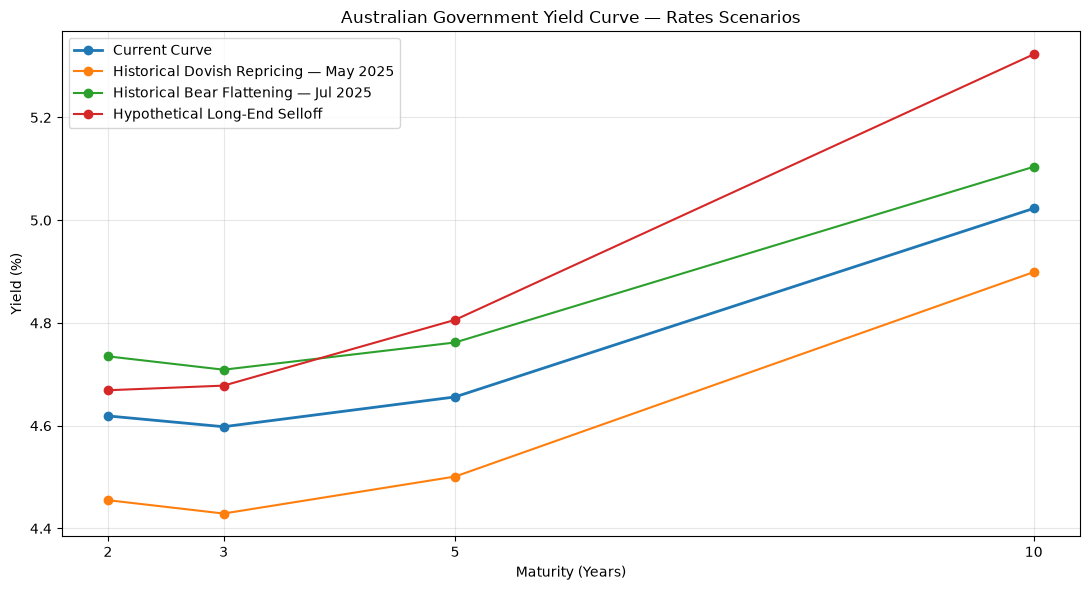

In [23]:
maturities = [2, 3, 5, 10]
tenors = ["2Y", "3Y", "5Y", "10Y"]

plt.figure(figsize=(11, 6))

plt.plot(
    maturities,
    [current_curve[t] for t in tenors],
    marker="o",
    linewidth=2,
    label="Current Curve"
)

for scenario_name, curve in scenario_curves.items():

    plt.plot(
        maturities,
        [curve[t] for t in tenors],
        marker="o",
        label=scenario_name
    )

plt.title("Australian Government Yield Curve — Rates Scenarios")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.xticks(maturities)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    "../outputs/charts/australian_rates_scenarios.png",

    dpi=300,

    bbox_inches="tight"

)
plt.show()

In [24]:
current_2s10s = (
    current_curve["10Y"] - current_curve["2Y"]
) * 100

scenario_summary = []

for scenario_name, shocks in scenarios.items():

    shocked_curve = scenario_curves[scenario_name]

    shocked_2s10s = (
        shocked_curve["10Y"] - shocked_curve["2Y"]
    ) * 100

    curve_change = shocked_2s10s - current_2s10s

    average_shock = np.mean(list(shocks.values()))

    if average_shock < 0:
        direction = "Bull"
    elif average_shock > 0:
        direction = "Bear"
    else:
        direction = "Neutral"

    if curve_change > 0:
        shape = "Steepening"
    elif curve_change < 0:
        shape = "Flattening"
    else:
        shape = "Unchanged"

    scenario_summary.append({
        "Scenario": scenario_name,
        "Average Yield Shock (bp)": average_shock,
        "2s10s Change (bp)": curve_change,
        "Curve Classification": f"{direction} {shape}"
    })

scenario_summary = pd.DataFrame(scenario_summary).round(1)

scenario_summary

,Scenario,Average Yield Shock (bp),2s10s Change (bp),Curve Classification
0,Historical Dovish Repricing — May 2025,-15.3,4.0,Bull Steepening
1,Historical Bear Flattening — Jul 2025,10.4,-3.5,Bear Flattening
2,Hypothetical Long-End Selloff,14.5,25.0,Bear Steepening


In [25]:
portfolio = pd.DataFrame({
    "Bond": ["2Y Bond", "5Y Bond", "10Y Bond"],
    "Coupon Rate": [0.040, 0.045, 0.050],
    "YTM": [
        current_curve["2Y"] / 100,
        current_curve["5Y"] / 100,
        current_curve["10Y"] / 100
    ],
    "Years": [2, 5, 10],
    "Frequency": [2, 2, 2],
    "Notional": [2_000_000, 3_000_000, 1_500_000],
    "Tenor": ["2Y", "5Y", "10Y"]
})

portfolio

,Bond,Coupon Rate,YTM,Years,Frequency,Notional,Tenor
0,2Y Bond,0.040,0.04619,2,2,2000000,2Y
1,5Y Bond,0.045,0.04656,5,2,3000000,5Y
2,10Y Bond,0.050,0.05023,10,2,1500000,10Y


In [26]:
def bond_price(face_value, coupon_rate, ytm, years, frequency=2):
    periods = int(years * frequency)
    coupon = face_value * coupon_rate / frequency
    periodic_yield = ytm / frequency

    price = 0

    for t in range(1, periods + 1):
        price += coupon / (1 + periodic_yield) ** t

    price += face_value / (1 + periodic_yield) ** periods

    return price

In [27]:
scenario_pnl_results = []

for scenario_name, shocks in scenarios.items():

    for _, bond in portfolio.iterrows():

        current_price = bond_price(
            100,
            bond["Coupon Rate"],
            bond["YTM"],
            bond["Years"],
            bond["Frequency"]
        )

        shock_bp = shocks[bond["Tenor"]]
        shocked_ytm = bond["YTM"] + shock_bp / 10000

        shocked_price = bond_price(
            100,
            bond["Coupon Rate"],
            shocked_ytm,
            bond["Years"],
            bond["Frequency"]
        )

        pnl = (
            (shocked_price - current_price)
            / 100
            * bond["Notional"]
        )

        scenario_pnl_results.append({
            "Scenario": scenario_name,
            "Bond": bond["Bond"],
            "Yield Shock (bp)": shock_bp,
            "Exact P&L ($)": pnl
        })

scenario_pnl = pd.DataFrame(scenario_pnl_results)

scenario_pnl.round(2)

,Scenario,Bond,Yield Shock (bp),Exact P&L ($)
0,Historical Dovish Repricing — May 2025,2Y Bond,-16.4,6163.94
1,Historical Dovish Repricing — May 2025,5Y Bond,-15.5,20530.07
2,Historical Dovish Repricing — May 2025,10Y Bond,-12.4,14551.53
3,Historical Bear Flattening — Jul 2025,2Y Bond,11.6,-4345.11
4,Historical Bear Flattening — Jul 2025,5Y Bond,10.6,-13945.03
5,Historical Bear Flattening — Jul 2025,10Y Bond,8.1,-9413.82
6,Hypothetical Long-End Selloff,2Y Bond,5.0,-1874.39
7,Hypothetical Long-End Selloff,5Y Bond,15.0,-19711.02
8,Hypothetical Long-End Selloff,10Y Bond,30.0,-34508.75


In [28]:
portfolio_scenario_pnl = (
    scenario_pnl
    .groupby("Scenario")["Exact P&L ($)"]
    .sum()
    .sort_values()
    .reset_index()
)

portfolio_scenario_pnl["Exact P&L ($)"] = (
    portfolio_scenario_pnl["Exact P&L ($)"]
    .round(2)
)

portfolio_scenario_pnl

,Scenario,Exact P&L ($)
0,Hypothetical Long-End Selloff,-56094.16
1,Historical Bear Flattening — Jul 2025,-27703.96
2,Historical Dovish Repricing — May 2025,41245.53


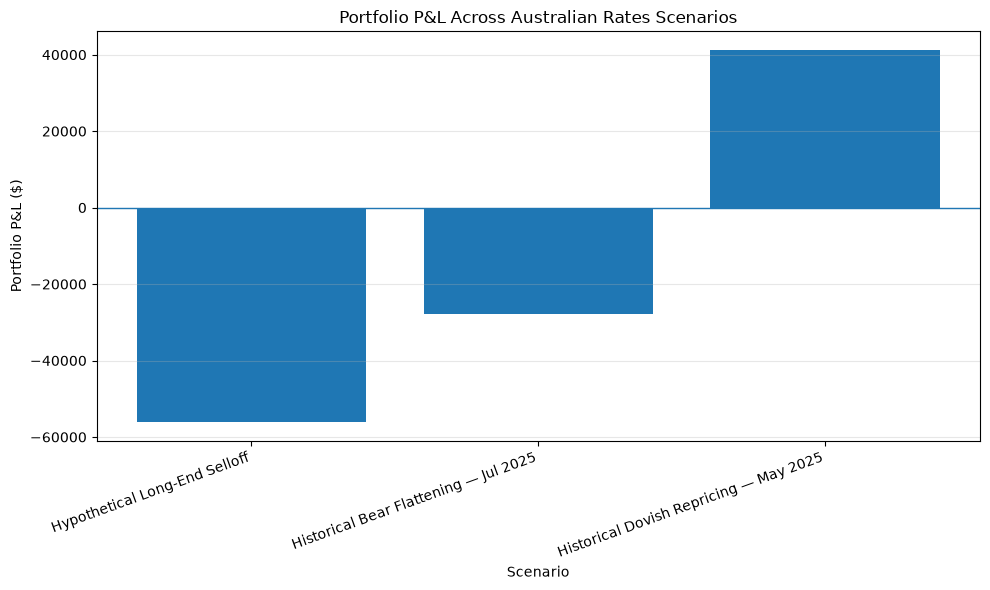

In [29]:
plt.figure(figsize=(10, 6))

plt.bar(
    portfolio_scenario_pnl["Scenario"],
    portfolio_scenario_pnl["Exact P&L ($)"]
)

plt.axhline(0, linewidth=1)

plt.title("Portfolio P&L Across Australian Rates Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Portfolio P&L ($)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/scenario_portfolio_pnl.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
scenario_summary.to_csv(
    "../outputs/tables/rates_scenario_summary.csv",
    index=False
)

scenario_pnl.to_csv(
    "../outputs/tables/rates_scenario_position_pnl.csv",
    index=False
)

portfolio_scenario_pnl.to_csv(
    "../outputs/tables/rates_scenario_portfolio_pnl.csv",
    index=False
)

print("Component 4 tables saved successfully.")

Component 4 tables saved successfully.


In [31]:
scenario_summary

,Scenario,Average Yield Shock (bp),2s10s Change (bp),Curve Classification
0,Historical Dovish Repricing — May 2025,-15.3,4.0,Bull Steepening
1,Historical Bear Flattening — Jul 2025,10.4,-3.5,Bear Flattening
2,Hypothetical Long-End Selloff,14.5,25.0,Bear Steepening


## Scenario Interpretation

This component combines the Australian yield-curve analysis, RBA event study and fixed-income risk engine to examine portfolio performance under different curve scenarios.

### Historical Dovish Repricing — May 2025

The May 2025 RBA event was associated with declines across the Australian Government bond curve, with front-end yields falling more than the 10-year yield. This produced a bull steepening of the curve.

For the illustrative long-only portfolio, falling yields generated positive P&L across the 2-year, 5-year and 10-year positions.

### Historical Bear Flattening — July 2025

The July 2025 event was associated with higher yields across the curve, with front-end yields rising more strongly than the long end. This produced a bear flattening.

The portfolio generated a loss because higher yields reduced bond prices, with the magnitude of the impact depending on each position's duration and notional exposure.

### Hypothetical Long-End Selloff

The hypothetical scenario applies a substantially larger rise in the 10-year yield than at the front end, producing a bear steepening.

This generated the largest portfolio loss among the scenarios tested. The result illustrates how long-duration exposure can become particularly vulnerable when the long end of the curve reprices sharply.

### Key Takeaway

The analysis demonstrates why a single parallel-shift assumption is insufficient for understanding rates risk. Different curve movements can generate materially different outcomes depending on where duration and DV01 are concentrated across the portfolio.

### Limitations

The portfolio positions and the long-end selloff scenario are illustrative. Historical scenarios reproduce observed one-day yield changes but do not imply that the same market response will recur. The analysis is intended as a scenario and risk-management framework rather than a forecast.